📊 **The Salary Dataset**

This dataset contains real-world salary information collected from multiple companies across different locations, job roles, and employment types. It is designed to help understand salary trends, pay distribution, and factors influencing compensation in the job market.

The dataset consists of 22,000+ records, making it suitable for exploratory data analysis (EDA), data cleaning, visualization, and business insights generation using Python.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("Salary_Dataset_DSL.csv")
df.head()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [3]:
df.shape

(22770, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22769 non-null  object 
 2   Job Title          22770 non-null  object 
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  object 
 6   Employment Status  22770 non-null  object 
 7   Job Roles          22770 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


In [5]:
df.isnull().sum()

Rating               0
Company Name         1
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64

In [6]:
df=df.dropna()

In [7]:
df.isnull().sum()

Rating               0
Company Name         0
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64

In [8]:
df.describe()

,Rating,Salary,Salaries Reported
count,22769.000000,2.276900e+04,22769.000000
mean,3.918209,6.953656e+05,1.855813
std,0.519686,8.844124e+05,6.823816
min,1.000000,2.112000e+03,1.000000
25%,3.700000,3.000000e+05,1.000000
50%,3.900000,5.000000e+05,1.000000
75%,4.200000,9.000000e+05,1.000000
max,5.000000,9.000000e+07,361.000000


In [9]:
df.duplicated().sum()

np.int64(0)

**Outlier Detection & Removal**

- Visualize Salary Outliers

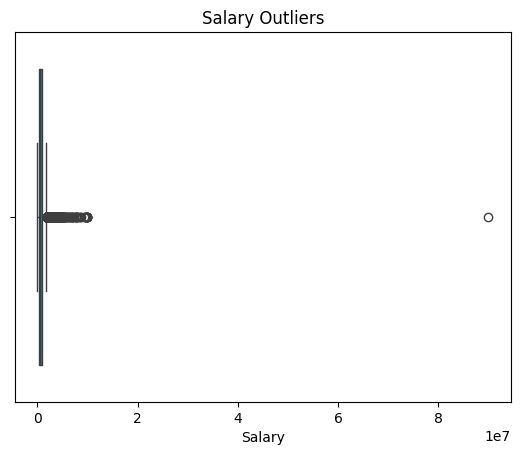

In [10]:
sns.boxplot(x="Salary",data=df)
plt.title("Salary Outliers")
plt.show()

In [11]:
q1=df["Salary"].quantile(0.25)
q3=df["Salary"].quantile(0.75)
iqr=q3-q1
iqr

np.float64(600000.0)

In [12]:
MinRange=q1-1.5*iqr
MaxRange=q3+1.5*iqr
MinRange,MaxRange

(np.float64(-600000.0), np.float64(1800000.0))

In [13]:
df=df[(df["Salary"]>=MinRange) & (df["Salary"]<=MaxRange)]

In [14]:
df.head()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [15]:
df.shape

(21613, 8)

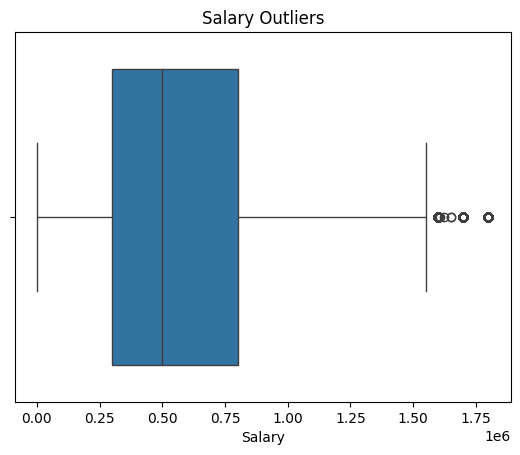

In [16]:
sns.boxplot(x="Salary",data=df)
plt.title("Salary Outliers")
plt.show()

In [17]:
q1=df["Salary"].quantile(0.25)
q3=df["Salary"].quantile(0.75)
iqr=q3-q1
iqr

np.float64(500000.0)

In [18]:
MinRange=q1-1.5*iqr
MaxRange=q3+1.5*iqr
MinRange,MaxRange

(np.float64(-450000.0), np.float64(1550000.0))

In [19]:
df=df[(df["Salary"]>=MinRange) & (df["Salary"]<=MaxRange)]

In [20]:
df.shape

(21013, 8)

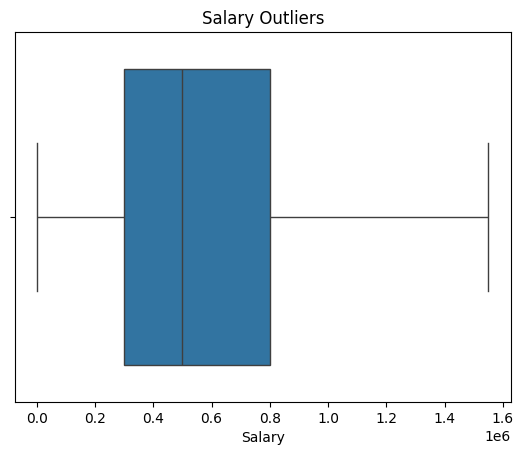

In [21]:
sns.boxplot(x="Salary",data=df)
plt.title("Salary Outliers")
plt.show()

**Univariate Analysis**

- Salary Distribution

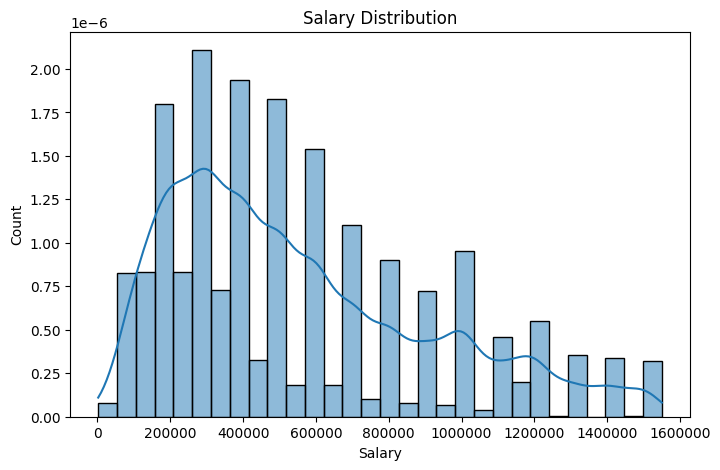

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(x="Salary",data=df,bins=30,kde=True,stat="density")

plt.ticklabel_format(style="plain",axis="x")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.title("Salary Distribution")
plt.show()

**Which Job Roles have the highest avarage salary?**

In [23]:
df.head()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [24]:
high_avg_sal=df.groupby("Job Roles")["Salary"].mean().reset_index().sort_values("Salary",ascending=False)
high_avg_sal

,Job Roles,Salary
2,Database,702554.768392
8,SDE,648108.015461
4,IOS,593214.068241
6,Mobile,589857.819905
1,Backend,529104.564347
3,Frontend,501977.282203
0,Android,483352.318634
5,Java,475832.116985
9,Testing,464824.757895
7,Python,449531.694295


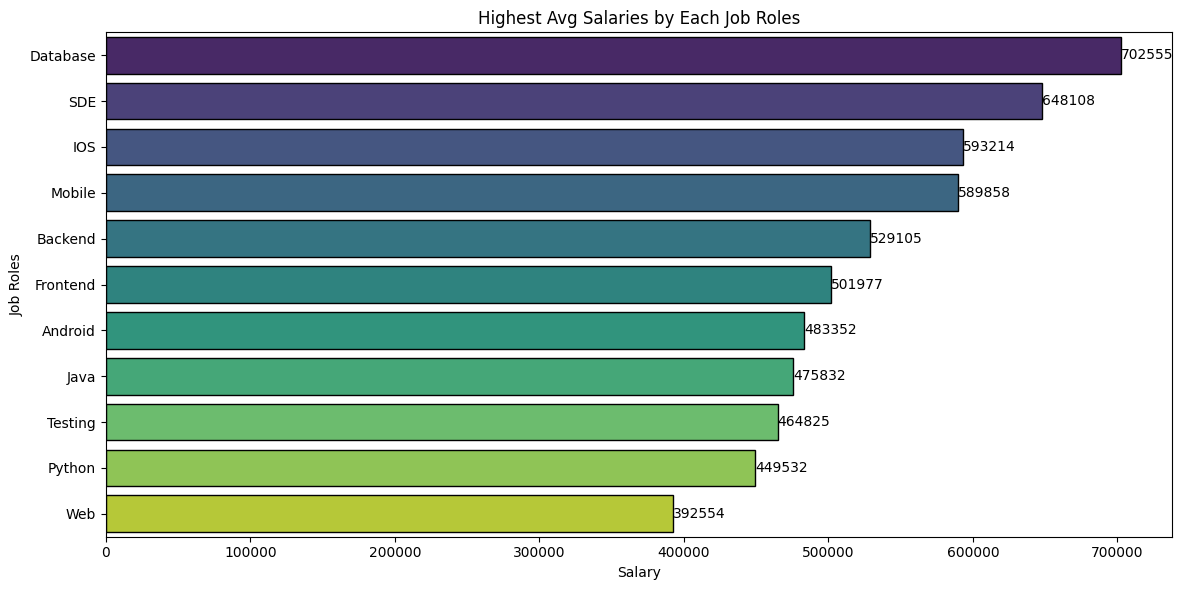

In [25]:
plt.figure(figsize=(12,6))
ax=sns.barplot(x="Salary",y="Job Roles",data=high_avg_sal,palette="viridis",edgecolor="black")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Highest Avg Salaries by Each Job Roles")
plt.tight_layout()
plt.show()

**Which Cities Offer Highest Average Salary?**

In [26]:
df.columns

Index(['Rating', 'Company Name', 'Job Title', 'Salary', 'Salaries Reported',
       'Location', 'Employment Status', 'Job Roles'],
      dtype='object')

In [27]:
sal_by_city=df.groupby("Location")["Salary"].mean().reset_index().sort_values("Salary",ascending=False)
sal_by_city

,Location,Salary
7,Mumbai,702195.874214
0,Bangalore,568140.303079
3,Jaipur,566153.846154
9,Pune,562387.138833
8,New Delhi,542717.057751
2,Hyderabad,538809.567450
5,Kolkata,532604.938272
4,Kerala,514965.735849
1,Chennai,505102.446337
6,Madhya Pradesh,497530.378378


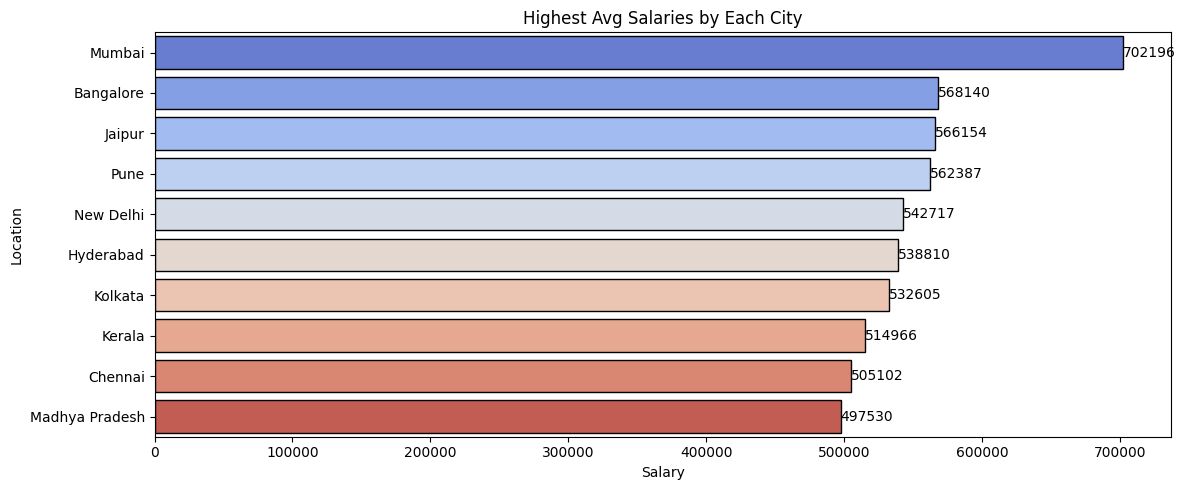

In [28]:
plt.figure(figsize=(12,5))
ax=sns.barplot(x="Salary",y="Location",data=sal_by_city,palette="coolwarm",edgecolor="black")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Highest Avg Salaries by Each City")
plt.tight_layout()
plt.show()

**Name those 5 companies located in 'New Delhi' with Ratings of '5',offering highest and lowest salaries.**

In [29]:
df.head()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [30]:
dt=df[(df["Location"]=="New Delhi") & (df["Rating"]==5)].sort_values("Salary",ascending=False)
dt

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
1888,5.0,Trillbit,Android Developer,1500000,1,New Delhi,Full Time,Android
6750,5.0,Hapramp,Front End Developer,1500000,1,New Delhi,Full Time,Frontend
17488,5.0,The Art of Mike Mignola,Software Development Engineer,1500000,1,New Delhi,Full Time,SDE
8284,5.0,Silicon Valley Recycling,Senior IOS Developer,1400000,1,New Delhi,Full Time,IOS
17351,5.0,Parth Universal,Software Development Engineer,1300000,1,New Delhi,Full Time,SDE
...,...,...,...,...,...,...,...,...
8008,5.0,Rabbler,IOS Developer Contractor,100000,1,New Delhi,Contractor,IOS
1969,5.0,WorkingNation,Android Developer - Intern,84000,1,New Delhi,Intern,Android
2334,5.0,Hopin (India),Android Developer - Intern,60000,1,New Delhi,Intern,Android
17524,5.0,Star Catalysts,Software Development Engineer - Intern,60000,1,New Delhi,Intern,SDE


In [31]:
top5_companies=list(dt["Company Name"].head())
top5_companies

['Trillbit',
 'Hapramp',
 'The Art of Mike Mignola',
 'Silicon Valley Recycling',
 'Parth Universal']

In [32]:
bottom5_companies=list(dt["Company Name"].tail())
bottom5_companies

['Rabbler', 'WorkingNation', 'Hopin (India)', 'Star Catalysts', 'Atom 8']

**Which Job Title has the highest number of salary reported?**

In [33]:
df["Job Title"].value_counts()

Job Title
Software Development Engineer               2136
Android Developer                           1983
Software Development Engineer (SDE)         1477
Front End Developer                         1360
Test Engineer                               1290
                                            ... 
Software Testing                               1
Automation Tester                              1
Web Developer/Android Developer - Intern       1
QA Analyst, Automation Test Engineer           1
Senior Test Lead                               1
Name: count, Length: 981, dtype: int64

In [34]:
df.groupby("Job Title")["Salaries Reported"].count().reset_index().sort_values("Salaries Reported",ascending=False)

,Job Title,Salaries Reported
758,Software Development Engineer,2136
25,Android Developer,1983
760,Software Development Engineer (SDE),1477
191,Front End Developer,1360
942,Test Engineer,1290
...,...,...
972,UI/User Experience Designer & Front End Developer,1
971,UI/UX Designer & Front End Developer,1
969,UI Front End Developer,1
967,Trainee Test Engineer - Contractor,1


**Which 10 Companies provide the highest average salary,when atleast 20 employees have reported their salaries?**

In [35]:
filtered_df=df[df['Salaries Reported']>=20]
filtered_df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
8790,3.9,Tata Consultancy Services,Java Developer,200000,30,Chennai,Full Time,Java
8977,3.8,Cognizant Technology Solutions,Senior Java Developer,200000,35,Chennai,Full Time,Java
8978,3.9,Tata Consultancy Services,Senior Java Developer,300000,30,Chennai,Full Time,Java
8979,3.9,Tata Consultancy Services,Junior Java Developer,200000,30,Chennai,Full Time,Java
9688,3.9,Tata Consultancy Services,Java Developer,200000,43,Hyderabad,Full Time,Java
...,...,...,...,...,...,...,...,...
21762,3.8,CGI,Senior Test Engineer,400000,21,Bangalore,Full Time,Testing
21763,4.1,IBM,Test Automation Engineer,400000,21,Bangalore,Full Time,Testing
21764,3.7,SLK Group,Software Test Engineer,300000,20,Bangalore,Full Time,SDE
21765,4.3,Cisco Systems,Software Test Engineer,700000,20,Bangalore,Full Time,SDE


In [36]:
filtered_df.groupby("Company Name")["Salary"].mean().reset_index().sort_values("Salary",ascending=False).head(10)

,Company Name,Salary
14,Expedia Group,1.350000e+06
29,Nokia,1.200000e+06
2,Amadeus,1.200000e+06
1,Alcatel-Lucent,1.000000e+06
32,Ola,1.000000e+06
22,Kony,9.000000e+05
24,Lumen,9.000000e+05
26,Microsoft,7.845714e+05
9,Cisco Systems,7.000000e+05
25,McAfee,6.500000e+05


**Check and show the relationship Between Ratings and Salaries.**

In [37]:
df["Rating"].corr(df["Salary"])

np.float64(0.024759533647245237)

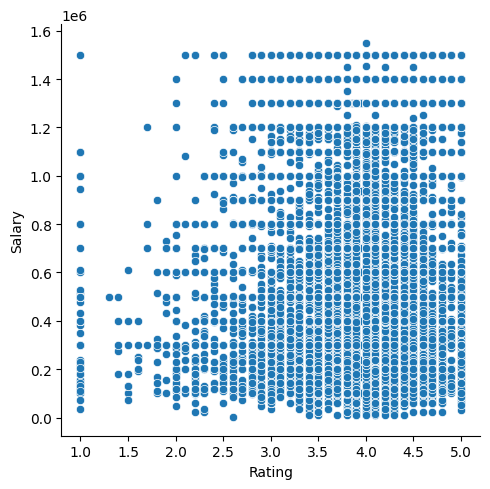

In [38]:
sns.relplot(x="Rating",y="Salary",data=df)
plt.show()

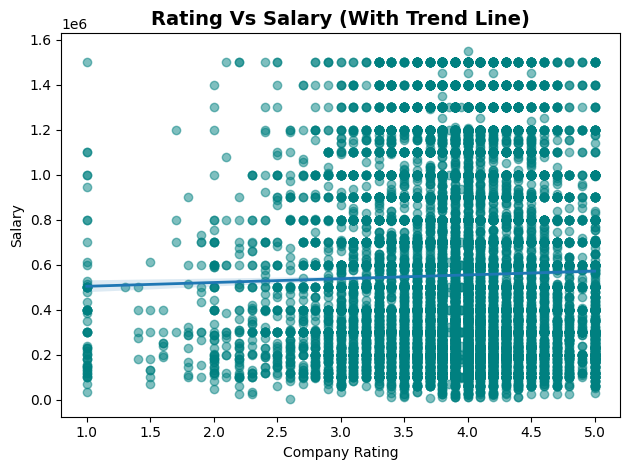

In [39]:
sns.regplot(x="Rating",y="Salary",data=df,scatter_kws={"alpha":0.5,"color":"teal"},line_kws={"linewidth":2})
plt.title("Rating Vs Salary (With Trend Line)",fontsize=14,fontweight="bold")
plt.xlabel("Company Rating")
plt.ylabel("Salary")
plt.tight_layout()
plt.show()

**Does employment status affect salary?**

In [40]:
df.columns

Index(['Rating', 'Company Name', 'Job Title', 'Salary', 'Salaries Reported',
       'Location', 'Employment Status', 'Job Roles'],
      dtype='object')

In [41]:
df["Employment Status"].unique()

array(['Full Time', 'Intern', 'Contractor', 'Trainee'], dtype=object)

In [42]:
df["Employment Status"].value_counts()

Employment Status
Full Time     18378
Intern         2089
Contractor      513
Trainee          33
Name: count, dtype: int64

In [43]:
df.groupby("Employment Status")["Salary"].describe()

,count,mean,std,min,25%,50%,75%,max
Employment Status,,,,,,,,
Contractor,513.0,501507.586745,315663.813209,12000.0,300000.0,400000.0,600000.0,1500000.0
Full Time,18378.0,579272.415279,358047.046792,8448.0,300000.0,500000.0,800000.0,1550000.0
Intern,2089.0,338353.991383,264180.887035,2112.0,144000.0,264000.0,456000.0,1500000.0
Trainee,33.0,324303.030303,241096.516572,96000.0,144000.0,240000.0,400000.0,1100000.0


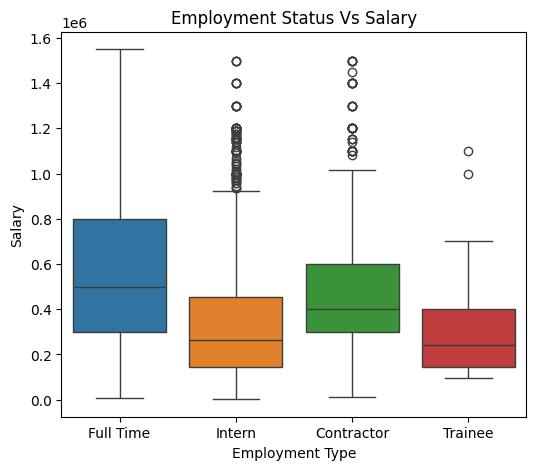

In [46]:
plt.figure(figsize=(6,5))
sns.boxplot(x="Employment Status",y="Salary",data=df,palette="tab10")
plt.title("Employment Status Vs Salary",fontsize=12)
plt.xlabel("Employment Type")
plt.ylabel("Salary")
plt.show()

**Which Job Roles are most common?**

In [47]:
df.columns

Index(['Rating', 'Company Name', 'Job Title', 'Salary', 'Salaries Reported',
       'Location', 'Employment Status', 'Job Roles'],
      dtype='object')

In [50]:
common_job_roles=df['Job Roles'].value_counts().reset_index()
common_job_roles

,Job Roles,count
0,SDE,7244
1,Android,2812
2,Frontend,2034
3,Java,1778
4,Testing,1710
5,IOS,1524
6,Backend,1049
7,Web,988
8,Python,929
9,Database,734


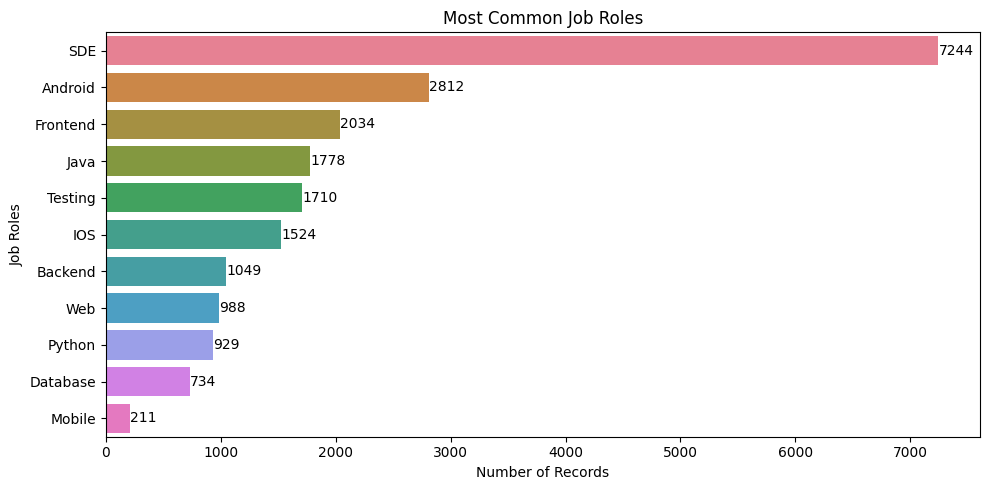

In [53]:
plt.figure(figsize=(10,5))
ax=sns.barplot(x="count",y="Job Roles",data=common_job_roles,palette="husl")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Most Common Job Roles")
plt.xlabel("Number of Records")
plt.ylabel("Job Roles")
plt.tight_layout()
plt.show()

**How does average salary change as company rating increases?**

In [54]:
df.columns

Index(['Rating', 'Company Name', 'Job Title', 'Salary', 'Salaries Reported',
       'Location', 'Employment Status', 'Job Roles'],
      dtype='object')

In [56]:
rating_salary=df.groupby("Rating")["Salary"].mean().reset_index()
rating_salary.head()

,Rating,Salary
0,1.0,399971.500000
1,1.3,500000.000000
2,1.4,331200.000000
3,1.5,241000.000000
4,1.6,262285.714286


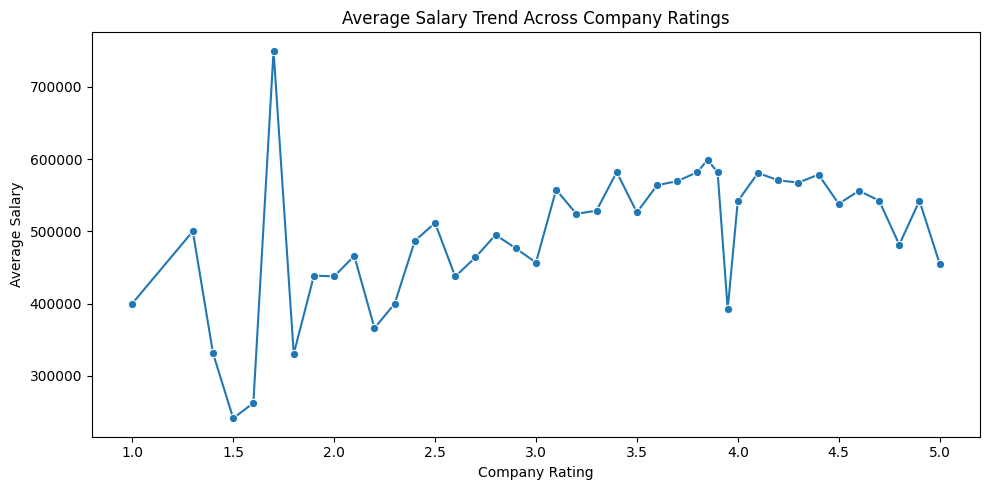

In [59]:
plt.figure(figsize=(10,5))
sns.lineplot(x="Rating",y="Salary",data=rating_salary,marker="o")
plt.title("Average Salary Trend Across Company Ratings")
plt.xlabel("Company Rating")
plt.ylabel("Average Salary")
plt.tight_layout()
plt.show()

**Mini Dashboard**

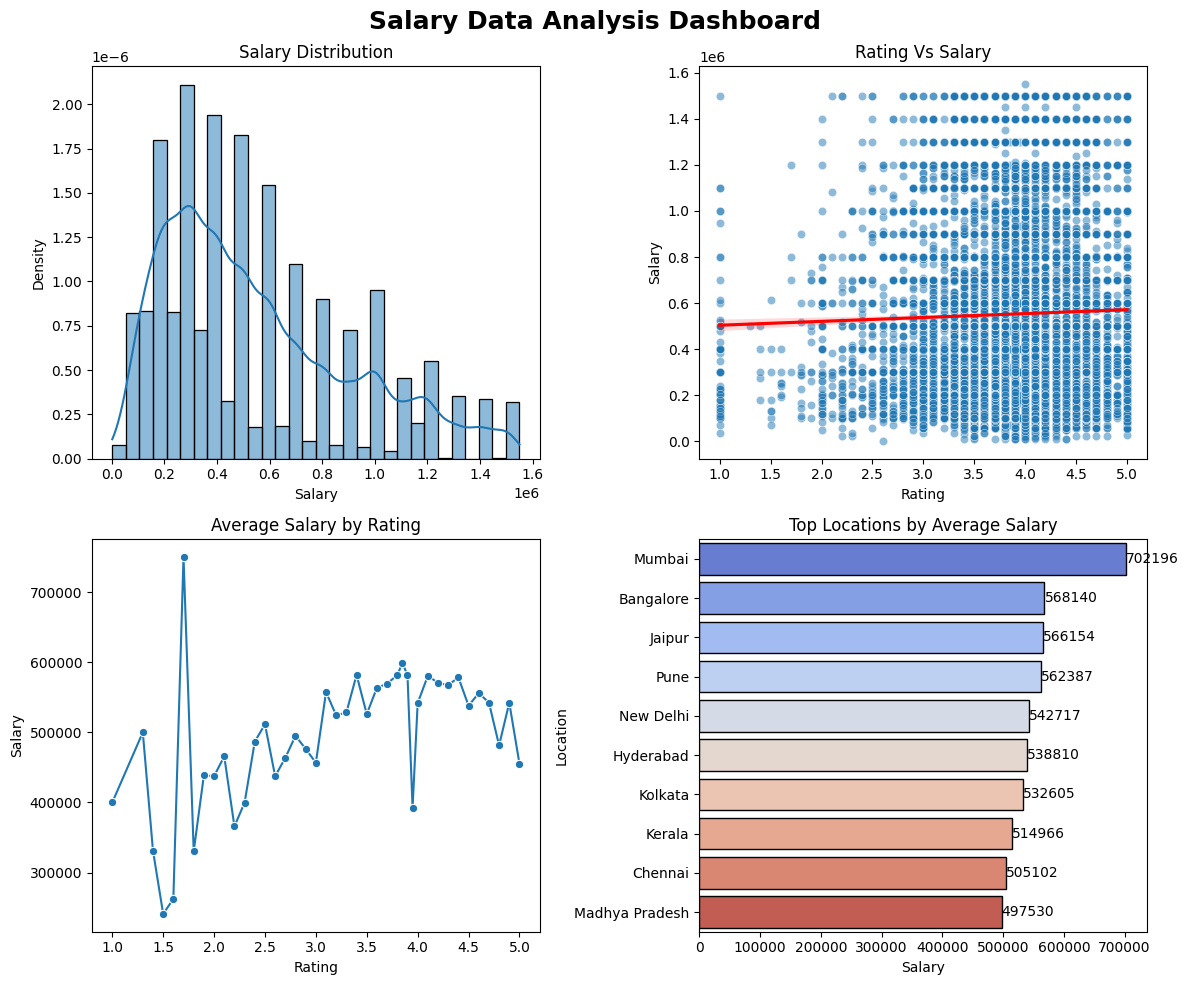

In [62]:
#Prepare data
rating_salary=df.groupby("Rating")["Salary"].mean().reset_index()
top_locations=df.groupby("Location")["Salary"].mean().reset_index().sort_values("Salary",ascending=False)

#Create Dashboard Layout
plt.figure(figsize=(12,10))
plt.suptitle("Salary Data Analysis Dashboard",fontsize=18,fontweight="bold")

#1. Salary Distribution
plt.subplot(2,2,1)
sns.histplot(df["Salary"],bins=30,kde=True,stat="density")
plt.title("Salary Distribution")

#2. Rating Vs Salary
plt.subplot(2,2,2)
sns.scatterplot(x="Rating",y="Salary",data=df,alpha=0.5)
sns.regplot(x="Rating",y="Salary",data=df,scatter=False,color="red")
plt.title("Rating Vs Salary")

#3. Average Salary by Rating
plt.subplot(2,2,3)
sns.lineplot(x="Rating",y="Salary",data=rating_salary,marker="o")
plt.title("Average Salary by Rating")

#4. Top Locations
plt.subplot(2,2,4)
ax=sns.barplot(x="Salary",y="Location",data=top_locations,palette="coolwarm",edgecolor="black")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Top Locations by Average Salary")

plt.tight_layout()
plt.show()

# Final Project Report: Salary Dataset Analysis

## 1. Project Overview & Methodology
This project analyzed a real-world tech salary dataset containing an initial **22,770 records**. The analysis followed a structured data science pipeline:
* **Data Cleaning:** Identified and removed 1 missing value from the `Company Name` column. 
* **Outlier Removal:** Applied the Interquartile Range (IQR) method twice to filter out extreme salary values. This successfully narrowed the data down from 22,770 rows to a finalized standard baseline of **21,013 rows** to ensure reliable average trends.
* **Exploratory Data Analysis (EDA):** Conducted univariate, bivariate, and multivariate analysis alongside data visualizations using `seaborn` and `matplotlib`.

---

## 2. Key Insights from the Data

### A. Salary Distribution
* **The Standard Bracket:** The vast majority of standard technology salaries in India are concentrated between **₹200,000 and ₹800,000** per year.
* **The Density Peak:** The single highest volume of tech professionals earns right around the **₹300,000** mark.

### B. High-Paying Job Roles vs. Market Volume
* **Highest Earners:** **Database** roles command the highest overall average salary at **₹702,555**, followed tightly by Software Development Engineers (**SDE**) at **₹648,108**.
* **Lowest Earners:** Traditional **Web Developers** sit at the bottom of the specialized job roles list, averaging **₹392,554**.
* **Market Prevalence:** **SDE** is by far the most common job role in the market with **7,244 records**, followed by **Android Developers** at **2,812 records**. **Mobile** roles are the rarest at only **211 records**.

### C. Geographic Performance (Top Cities)
* **Premium Market:** **Mumbai** leads all locations, offering the highest average compensation package at **₹702,196**.
* **The Tech Baseline:** Established tech hubs like **Bangalore (₹568,140)**, **Jaipur (₹566,154)**, and **Pune (₹562,387)** operate on highly competitive, nearly identical average baselines.

### D. The Relationship Between Ratings and Salaries
* **No Linear Connection:** The statistical correlation between a company's rating and the salary it offers is nearly zero (**r = 0.0248**). 
* **The Reality:** A 5-star rating on career platforms does not guarantee higher pay than a 3-star company. High-paying and low-paying jobs exist randomly across almost all rating tiers.

### E. Employment Status Impact
* **Full-Time Advantage:** **Full-Time** employees receive the highest average compensation at **₹579,272**, followed by **Contractors** at **₹501,507**.
* **Early Career Levels:** **Interns (₹338,354)** and **Trainees (₹324,303)** predictably occupy the lowest brackets.

### F. High-Volume Employer Benchmarks (Minimum 20 Salary Reports)
* When filtering for stable corporate trends with a strong reporting base, **Expedia Group** provides the highest average package at **₹1,350,000**.
* **Nokia** and **Amadeus** are tied as runners-up, both maintaining average payouts of **₹1,200,000**.

---

## 3. Project Conclusions

1. **Role and Location Control Compensation:** Job role specialization and corporate location dictate earning potential far more than company reviews. Aspiring professionals will find the highest financial returns by targeting **Database or SDE specialisations** based out of **Mumbai or Bangalore**.
2. **Company Ratings are Deceptive Financial Indicators:** Since company rating values have no correlation with pay checks, job seekers should prioritize corporate ratings for work-life culture, benefits, or stability rather than salary growth expectations.
3. **Market Saturation Strategy:** SDE and Android roles offer excellent pay but suffer from severe talent saturation. Professionals looking to minimize job competition while protecting salary metrics should focus on high-value niche skills like Database engineering.